# Efectos. DSP (Digital Signal Processing)

Un efecto, en sentido general, es cualquier transformación de señal de audio

- Un control de volumen, una envolvente o un modulador de volumen son efectos en ese sentido

Pueden distinguirse 2 tipos de efectos en función del dominio de trabajo

  1. Sobre la amplitud: envolventes, fade in/out, moduladores de volumen, compresores, limitadores, normalizadores, eco, distorsión,...

  2. Sobre la frecuencia: ecualizadores, filtros (paso bajo, paso alto, paso banda...)

      Muchos, en realidad, son *híbridos*: actuan sobre ambos dominios.

# Filtros (en sentido habitual)

##### (En algunos contextos cualquier procesador de señal es un *filtro*))

Qué hacen? $\leadsto$ transforman el sonido eliminando o atenuando frecuencias de manera selectiva. Los clásicos:

- Low pass LP (paso bajo): eliminan frecuencias altas (dejan pasar graves)

- Hihg pass HP (paso alto): eliminan frecuencias baja (dejan pasar agudos)

- Band pass BP (paso banda): pasa una porción dentro de una banda centrada en una frecuencia; elimina componentes fuera de esa banda.

- Band reject BR: al revés, descarta las frecuencias dentro de la banda.

- All pass AP: pasan todas, pero altera la fase de la señal de entrada.

![image](media/tipos_filtros.png)



## Dos conceptos clave:

- **Frecuencia(s) de corte** (*cutoff frequency*): frecuencia a partir de la cual actúa el filtro.

- **Resonance o quality factor (Q)**: cómo de abruta es la pendiente del filtro en la frecuencia de corte.

## Qué hace un filtro con las muestras?

Formalmente, un *filtro digital* transforma un conjunto de muestras $\overline{x}$ (input) en otro $\overline{y}$ (output)

$$x[0,\ldots] \leadsto y[0,\ldots]$$

donde $\overline{y}$ se define en función de las muestras de entrada $\overline{x}$ (y posiblemente sobre las previas de salida). Forma general:

$$y[n]=\sum_{i=0}^N a_i*x[n-i] - b_i*y[n-i]$$

La clave está en los coeficientes $a_i$, $b_i$

El filtro más simple (media entre una muestra y la anterior)

$$y[n] = \frac{x[n-1]+x[n]}{2} = 0.5*x[n-1] +0.5*x[n]$$

es decir: $N=1$, $a_0=a_1=0.5$ y $b_0=b_1=0$

... qué hace este filtro? Vamos a escucharlo!

# Contexto para probar los filtros

### Clase Player

Generador de señal que toma la entrada de un archivo de audio

- Ojo: *resampleamos a SRATE* (con librosa), sea cual sea el srate del audio leído para unificar al SRATE del proyecto

In [1]:
!pip install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 79.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 47.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 44.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23/23 [librosa]1/23 [audioread]rn]lizer]


In [3]:
%%writefile files/player.py

import sys
sys.path.insert(0, "./files")        

from consts import *
import numpy as np
import soundfile as sf
import librosa

class Player:
    def __init__(self, file):
        # leemos archivo de audio, data y srate del archivo
        data, srate = sf.read(file,dtype=np.float32)       
        # resampleamos data a SRATE
        self.data = librosa.resample(data, orig_sr=srate, target_sr=SRATE)     
        self.finished = False
        self.frame = 0

    def next(self):
        if self.frame+CHUNK>len(self.data): # si no queda suficiente data, rellenamos con ceros
            self.finished = True
            return np.pad(self.data[self.frame:],(0,CHUNK-len(self.data[self.frame:])),mode='constant')
        else:
            ret = self.data[self.frame:self.frame+CHUNK]
            self.frame += CHUNK
            return ret

    def isFinished(self):
        return self.finished
    
    def sRate(self):
        return self.SRATE

Overwriting files/player.py


#### Nuestro filtro

$$y[n] = \frac{x[n-1]+x[n]}{2}$$

Implementado como procesador de señal:

- Recibe una señal con  *next*

- Devuelve señal con *next* (devuelve audio procesado, filtrado)


Un detalle:

- Cómo calculamos $y[0]$? (no existe $x[-1]$) $\leadsto$ consideramos $x[-1]=0$ (silencio)

- Cómo *conectamos* chunks? En general, un chunk necesita el último sample del chunk anterior para hacer la media con el primer sample del actual

$\leadsto$ El filtro tendrá una **memoria de un sample**


#### Importante

Evitar en la medida de lo posible recorridos explícitos sobre arrays, que haga el trabajo *numpy*!

In [4]:
%%writefile files/filter.py

import sys
sys.path.insert(0, "./files")  

from consts import *

class Filter:
    def __init__(self,signal):
        self.signal = signal
        # memoria con la última muestra del bloque anterior, para el cálculo de la primera muestra del bloque actual
        # inicialmente silencio
        self.mem = 0
        # por defecto inactivo
        self.act = False

    def next(self):
        data = self.signal.next()

        if self.act:
            data[1:]=0.5*(data[0:-1]+data[1:]) # media entre cada muestra y la siguiente
            data[0] = 0.5*(self.mem+data[0]) # la primera muestra se calcula por separado, utilizando la última del bloque anterior

        self.mem = data[-1] # actualizamos memo con ultima muestra
        return data

    def activate(self):
        self.act = True

    def deactivate(self):
        self.act = False    

    def isActive(self):
        return self.act



Writing files/filter.py


# Prueba del filtro. Para este ejemplo, cambiar en files/const.py 
# SRATE=16000

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "./files")  

import numpy as np
import sounddevice as sd
import soundfile as sf

from consts import *
from player import Player
from filter import Filter

from tkinter import *


# stream de salida con callBack
input = None
def callback(outdata, frames, time, status):
    if status: print(status)
    if input:    
        s = input.next()
        s = np.float32(s)
    else:
        s = np.zeros(CHUNK,dtype=np.float32)
    outdata[:] = s.reshape(-1, 1)

# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, callback=callback, blocksize=CHUNK)
stream.start()


signal = Player('media/piano.wav')
signalFiltered = Filter(signal)
input = signalFiltered


# inicialización de la ventanas 
tk=Tk()

# Caja de texto
text = Text(tk,height=6,width=60)
text.pack(side=BOTTOM)
text.insert(INSERT,"Press 'F/f' to activate/deactivate filter\n")

# call back para la pulsación de teclas
def key_down(event):
    if event.char=='F': 
        text.insert(INSERT,f'\nFilter active  ')
        signalFiltered.activate()
    elif event.char=='f': 
        text.insert(INSERT,f'\nFilter bypassed  ')
        signalFiltered.deactivate()

# enlace de la pulsación de teclas con la función key_down
text.bind('<Key>', key_down)


# arrancamos todo!!
tk.mainloop()
# ejecución bloqueada hasta que se cierre ventana

stream.stop()       
stream.close()

output underflow


# Qué hace exactamente este filtro?

Cómo se comporta este filtro con una señal dada?

- Para simplificar aún más consideramos $y[n] = x[n-1]+x[n]$ (es decir, no hacemos media)

- cómo se comporta para una frecuencia dada?

![image](media/lp_in-out.png)

-   Incrementa la amplitud hasta $\sqrt{2}$

-   Desplaza la fase en $-2*\pi/8$

Para profundizar: *Introduction to Digital Filters with Audio Applications*, by Julius O.
Smith III, (September 2007 Edition).



## Después se estudia cómo se comporta para *cada una de las frecuencias*

Analizando este filtro para cada seno ($f_s$ = frecuencia de muestreo)

![image](media/lp_response.png)

Para un análisis matemático detallado:

<https://ccrma.stanford.edu/~jos/filters/Mathematical_Sine_Wave_Analysis.html>



# Cómo transforma (gráficamente) la forma de onda?

Aplicamos este filtro LP a la tormenta:


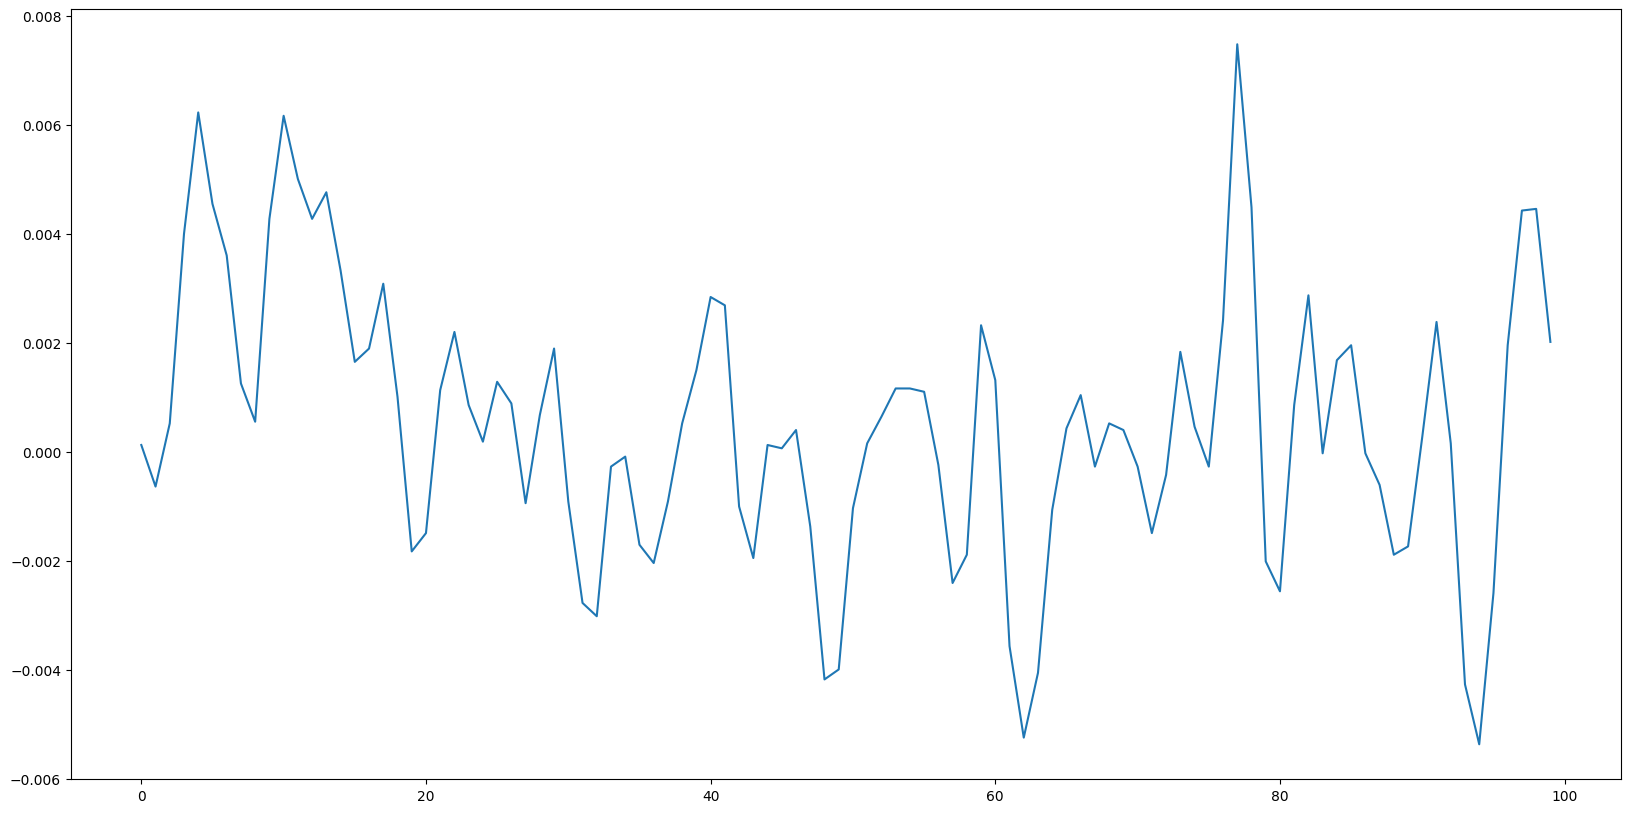

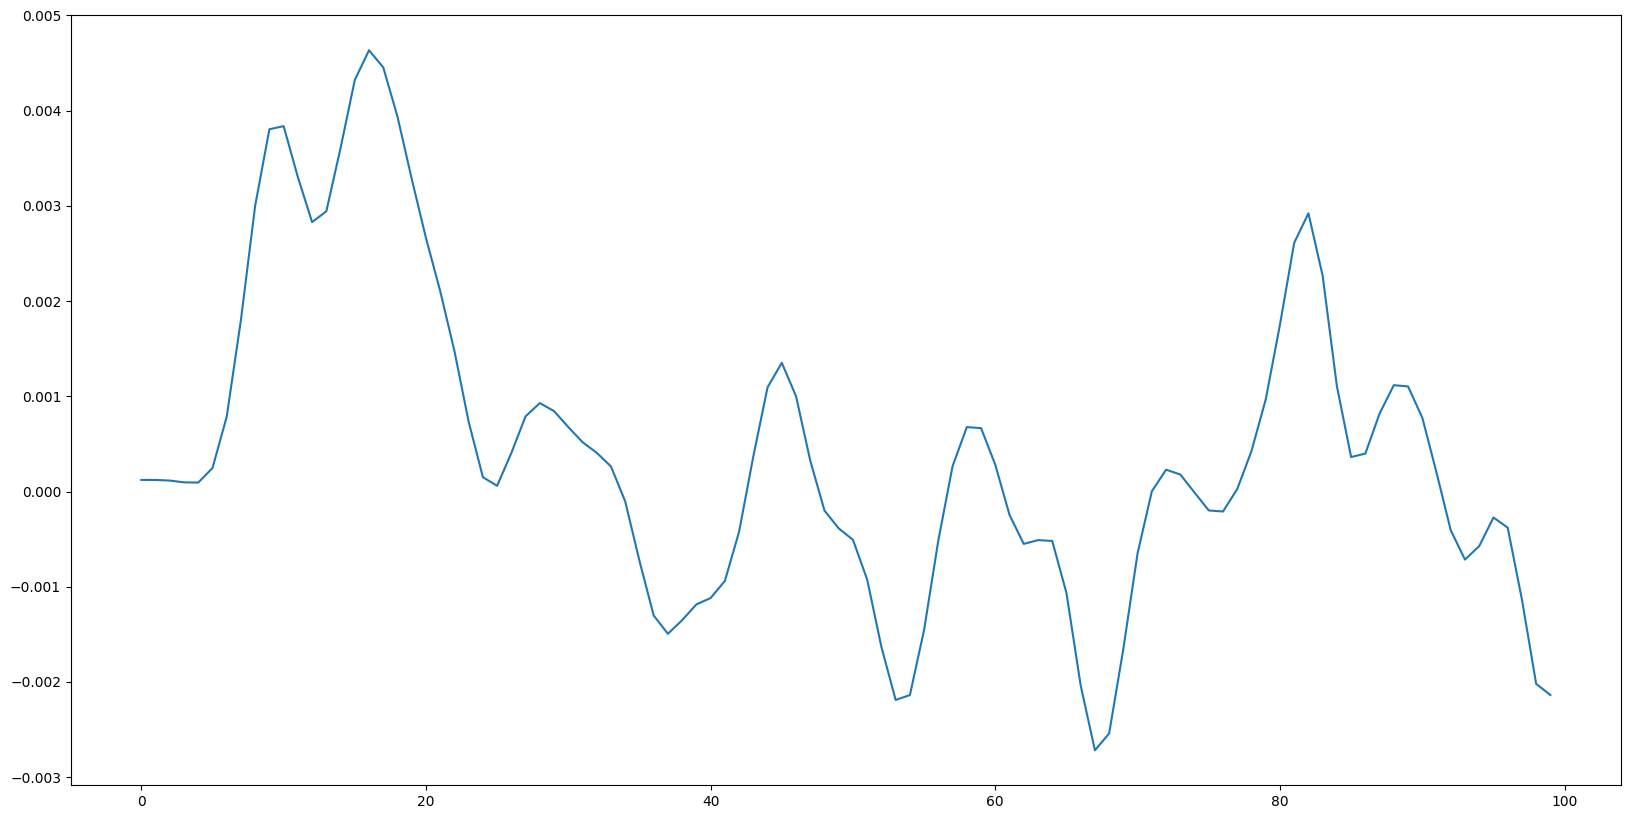

In [9]:
import sys
sys.path.insert(0, "./files")  

import numpy as np
import matplotlib.pyplot as plt
from consts import *
import soundfile as sf

%matplotlib inline

data, SRATE = sf.read('media/tormenta.wav',dtype=np.float32)

#%% filtrado
CHUNK = 100 # solo para dibujar

nBloque = 0
original = data[nBloque*CHUNK:(nBloque+1)*CHUNK]
filtrada  = np.copy(original)

# varias pasadas de filtro para exagerar el efecto
N=10
for j in range(N):
    filtrada[1:] = 0.5*(filtrada[0:CHUNK-1]+filtrada[1:CHUNK])



#%% dibujamos original y filtrada
plt.figure(figsize=(20,10))
plt.plot(original)

plt.figure(figsize=(20,10))
plt.plot(filtrada)


# FIR y IIR

- El filtro anterior es un filtro FIR (*finite impulse response*). En general, un FIR es:

  $y[n] = b_0 * x[n] + b_1 * x[n-1] + \ldots + b_* x[n-N]$

  $x$: entrada; $y$ salida; $N$ orden del filtro; $b_i$ coeficientes del filtro

- Los filtros IIR (*infinite impulse response*) se definen como: 

  $$y[n] = \quad b_0 * x[n] + b_1 * x[n-1] + \ldots + b_N* x[n-N]\\
       \qquad\qquad\qquad -a_1 *y[n-1] - a_2*y[n-2] -\ldots - a_M*y[n-M]
    $$

**Diseño de filtros** cálculo de coeficientes $a_i,b_i$ para conseguir salida correspondiente: 
- frecuencia de corte, fase, amplitud
- y otras propiedades: linealidad, estabilidad, etc.

(Ampliamente estudiado en cursos de DSP)

# Un filtro IIR fácil

Un filtro LP un poco más sofisticado que el anterior:

$$y[n] = \alpha *y[n-1] + (1-\alpha)*x[n]$$

El coeficiente $\alpha$ determina la frecuencia de corte

**Importante:** ahora sí hay que hacer un bucle!! En una asignación como la de arriba, numpy

-  calcularía todo el lado derecho y luego lo asignaría al lado izdo ($y[n]$)... no es lo que queremos

No se puede hacer recursión en numpy de esta manera


In [21]:
# Experimento: numpy primero calcula todo el lado dcho y luego asigna al izdo
b = np.arange(10,dtype=np.float32)
alpha =0.5

print('Experimento: ') # no funciona como queremos
b[1:] = b[0:-1] + alpha*(b[1:]-b[0:-1]) 
b[0]  = 0 + alpha*(b[0]-0)

# versión correcta
c = np.arange(10,dtype=np.float32)
c[0] = 0 + alpha * (c[0]-0)
for i in range(1,len(c)):
    c[i] = c[i-1] + alpha * (c[i]-c[i-1])

# comparamos resultados
print(b)
print(c)

Experimento: 
[0.  0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5]
[0.        0.5       1.25      2.125     3.0625    4.03125   5.015625
 6.0078125 7.0039062 8.001953 ]


In [22]:
%%writefile files/filterIIR.py

import sys
sys.path.insert(0, "./files")       

from consts import *

class FilterIIR:
    def __init__(self,signal,alpha,step=0.01):
        self.signal = signal
        self.mem = 0
        self.alpha = alpha
        self.step = step
        # por defecto inactivo
        self.act = False

    def next(self):
        data = self.signal.next()
        if self.act:
            data[0] = self.mem + self.alpha * (data[0]-self.mem)
            for i in range(1,CHUNK):
                data[i] = data[i-1] + self.alpha * (data[i]-data[i-1])
            self.mem = data[CHUNK-1]
        self.mem = data[-1] # actualizamos memo con ultima muestra
        return data

    def activate(self):
        self.act = True

    def deactivate(self):
        self.act = False    

    def isActive(self):
        return self.act

    def upAlpha(self):
        self.alpha = min(2.0,max(0.1,self.alpha+self.step))

    def downAlpha(self):
        self.alpha = min(2.0,max(0.1,self.alpha-self.step))

Writing files/filterIIR.py


In [6]:
import sys
sys.path.insert(0, "./files")      

from consts import *
from player import Player
from filterIIR import FilterIIR
import numpy as np
import sounddevice as sd
import soundfile as sf
from tkinter import *



# stream de salida con callBack
input = None
def callback(outdata, frames, time, status):
    if status: print(status)
    if input:    
        s = input.next()
        s = np.float32(s)
    else:
        s = np.zeros(CHUNK,dtype=np.float32)
    outdata[:] = s.reshape(-1, 1)

# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, callback=callback, blocksize=CHUNK)
stream.start()


signal = Player('media/tormenta.wav')
signalFiltered = FilterIIR(signal,alpha=0.5,step=0.05)
input = signalFiltered


# inicialización de la ventanas 
tk=Tk()

# Caja de texto
text = Text(tk,height=6,width=60)
text.pack(side=BOTTOM)
text.insert(INSERT,"Press 'F/f' to activate/deactivate filter\n")
text.insert(INSERT,"[A/a] sube baja alpha")


# call back para la pulsación de teclas
def key_down(event):
    if event.char=='F': 
        signalFiltered.activate()
    elif event.char=='f': 
        signalFiltered.deactivate()
    elif event.char=='A':
        signalFiltered.upAlpha()        
    elif event.char=='a':  
        signalFiltered.downAlpha()

    act = "active" if signalFiltered.isActive() else "bypassed"
    text.insert(INSERT,f'\nFilter {act}  Alpha: {signalFiltered.alpha}')        

# enlace de la pulsación de teclas con la función key_down
text.bind('<Key>', key_down)


# arrancamos todo!!
tk.mainloop()
# ejecución bloqueada hasta que se cierre ventana


stream.stop()       
stream.close()


-   Qué ocurre con `alpha = 1`?
-   Y con `alpha = 0, alpha = 2`?

# Cómo hacemos un filtro HP?

Solo hemos visto filtros paso bajo (LP)... cómo hacemos uno HP (paso alto)?

Idea, dada una señal $x[n]$

-   Obtener la señal filtrada $y[n]$ mediante un filtro LP

-   Restar a la señal original $x[n]$ la señal filtrada $y[n]$

$$z[n]=x[n]-y[n]$$

## Cómo determinamos la frecuencia de corte?

En función de `alpha`:

$$alpha = e^{-2*\pi*freq/SRATE}$$



# Más sobre filtros

-   *Introduction to Digital Filters with Audio Applications*, Julius O. Smith III, (September 2007 Edition). (online)

-   *The Scientist and Engineer's Guide to Digital Signal Processing*, Second Edition, Steven W. Smith, 1999,
    (www.DSPguide.com)

-   *Real sound synthesis for interactive applications*, Perry  Cook, 2002.

DSP en NumPy:

<https://docs.scipy.org/doc/scipy/reference/signal.html>

También ofrece:

-  **Correlación**: *medida de la similitud entre señales* (análisis de espectro)

-  **Convolución**: *efecto de aplicar una señal a otra* (efectos)

-  **FFT**: transformada rápida de Fourier $\leadsto$ eficiencia en las operaciones (tiempo real)
